<a href="https://colab.research.google.com/github/SundeepChaluvadi/PyTorch-Tutorial/blob/main/Simple_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [455]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

In [456]:
# Create a model class that inherits nn.module
class Model(nn.Module):
  # Input Layer (4 Features of the flower) -> Hidden Layer1 (n number of neurons) -> Hidden Layer2 (n number of neurons) -> output (3 classes of IRIS flowers)
  def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    super().__init__() # instantiate our nn.module
    # fc1: Fully Connected
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, out_features)

  # Function to move everything forward
  def forward(self, x):
    # relu: rectified linear unit (if < 0, 0; else > 0, use the output)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)

    return x



In [457]:
# For neural networks, we need a SEED (a starting point)
# Pick a manual seed for randomization
torch.manual_seed(32)

# Create a instance of model
model = Model()

In [458]:
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

In [459]:
url = r'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
df = pd.read_csv(url)

In [460]:
df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [461]:
# Change last column from string to integer
df['species'] = df['species'].replace('setosa', 0.0)
df['species'] = df['species'].replace('versicolor', 1.0)
df['species'] = df['species'].replace('virginica', 2.0)

/tmp/ipykernel_1676/3702803228.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['species'] = df['species'].replace('virginica', 2.0)


In [462]:
df['species'].unique()

array([0., 1., 2.])

In [463]:
# Train, Test and Split - X and y
X = df.drop('species', axis=1)
y = df['species']

In [464]:
# Convert X and y to numpy arrays
print(type(X))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [465]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [466]:
y

,species
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
145,2.0
146,2.0
147,2.0
148,2.0


In [467]:
from sklearn.model_selection import train_test_split

In [468]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32)

In [469]:
# Convert X features to float tensors
X_train = torch.FloatTensor(X_train.values)
X_test = torch.FloatTensor(X_test.values)

# Convert y labels to long tensors
y_train = torch.tensor(y_train.to_numpy(), dtype=torch.long)
y_test = torch.tensor(y_test.to_numpy(), dtype=torch.long)


print(type(y_train), type(y_test))

<class 'torch.Tensor'> <class 'torch.Tensor'>


In [470]:
print(type(X_train))
print(type(y_train))
print(y_train.dtype)

<class 'torch.Tensor'>
<class 'torch.Tensor'>
torch.int64


In [471]:
# set the criteria of the model to measure the error, how far off the predictions are from the data
criterion = nn.CrossEntropyLoss()

# Choose an optimizer - Adam
# learning rate - lr (if error doesn't go down after a bunch of iterations (epochs), lower our learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [472]:
# Train our model
# Epochs ? (one run through all the training data in our network)
epochs = 200
losses = []
for i in range(epochs):
  # Go forward and get a prediction
  y_pred = model.forward(X_train) # to get predicted results

  # Measure the loss/error, gonna be high at first
  loss = criterion(y_pred, y_train) # predicted value vs y_train value

  # keep track of our losses
  losses.append(loss.detach().cpu().numpy())

  # Print every 10 epoch
  if i % 10 == 0:
    print(f'Epoch: {i} and Loss: {loss}')

  # Do some back propagation: take the error rate of forward propagation and feed it back through the network to finetune the weights
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()




Epoch: 0 and Loss: 1.169895887374878
Epoch: 10 and Loss: 0.9578844308853149
Epoch: 20 and Loss: 0.7988812923431396
Epoch: 30 and Loss: 0.634953498840332
Epoch: 40 and Loss: 0.44043001532554626
Epoch: 50 and Loss: 0.291716992855072
Epoch: 60 and Loss: 0.17829042673110962
Epoch: 70 and Loss: 0.11587586998939514
Epoch: 80 and Loss: 0.08928147703409195
Epoch: 90 and Loss: 0.07743765413761139
Epoch: 100 and Loss: 0.07124082744121552
Epoch: 110 and Loss: 0.06744465976953506
Epoch: 120 and Loss: 0.06482169777154922
Epoch: 130 and Loss: 0.06285709887742996
Epoch: 140 and Loss: 0.06129826232790947
Epoch: 150 and Loss: 0.06000852212309837
Epoch: 160 and Loss: 0.058905504643917084
Epoch: 170 and Loss: 0.057936906814575195
Epoch: 180 and Loss: 0.057068951427936554
Epoch: 190 and Loss: 0.056279949843883514


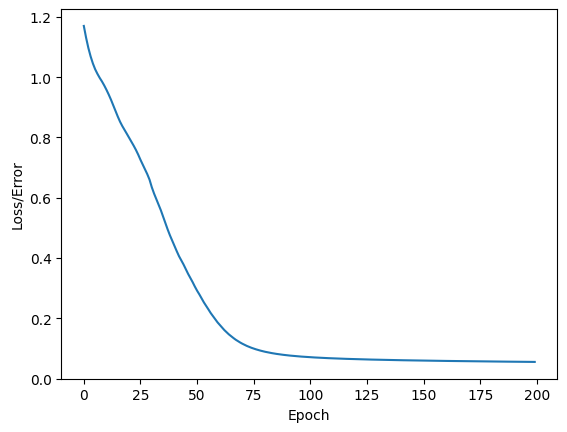

In [473]:
# Graph it out
plt.plot(range(epochs), losses)
plt.ylabel('Loss/Error')
plt.xlabel('Epoch')
plt.show()

In [474]:
# Evaluate our model on test dataset (validate data on test set)
with torch.no_grad(): # Basically turn off back propagation
  y_eval = model.forward(X_test) # X_test are features from our test set, y_eval will be predictions
  loss = criterion(y_eval, y_test) # find the loss / error

In [475]:
# 0.1816 vs 0.0184
loss

tensor(0.0298)

In [476]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    if y_test[i] == 0:
      x = 'setosa'
    elif y_test[i] == 1:
      x = 'versicolor'
    else:
      x = 'virginica'

    # will tell us what type of flower class our network thinks it is
    print(f'{i+1} -> {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}')

    # correct or not
    if y_val.argmax().item() == y_test[i]:
      correct += 1

1 -> tensor([-4.5474,  5.6474,  0.6258]) 	 1 	 1
2 -> tensor([  9.7839,   2.0130, -14.4508]) 	 0 	 0
3 -> tensor([  8.7851,   2.2439, -13.3628]) 	 0 	 0
4 -> tensor([-4.7777,  5.9443,  0.5937]) 	 1 	 1
5 -> tensor([-9.7693,  3.8727,  7.0655]) 	 2 	 2
6 -> tensor([-10.4429,   5.0144,   6.8463]) 	 2 	 2
7 -> tensor([  8.1658,   2.5038, -12.7315]) 	 0 	 0
8 -> tensor([  9.2193,   2.0836, -13.7833]) 	 0 	 0
9 -> tensor([-4.0243,  5.9801, -0.2057]) 	 1 	 1
10 -> tensor([  9.5090,   2.0918, -14.1647]) 	 0 	 0
11 -> tensor([-4.9568,  6.4096,  0.5537]) 	 1 	 1
12 -> tensor([-11.6292,   2.6205,   9.6212]) 	 2 	 2
13 -> tensor([-2.2209,  5.4773, -1.5542]) 	 1 	 1
14 -> tensor([-1.4594,  6.1748, -2.9049]) 	 1 	 1
15 -> tensor([-9.9357,  3.6303,  7.3054]) 	 2 	 2
16 -> tensor([-11.2093,   2.2251,   9.4723]) 	 2 	 2
17 -> tensor([-5.2317,  5.1326,  1.6100]) 	 1 	 1
18 -> tensor([-8.7368,  4.0250,  5.8872]) 	 2 	 2
19 -> tensor([-2.0934,  5.9443, -2.0632]) 	 1 	 1
20 -> tensor([ 10.2769,   2.1301, -

In [477]:
print(f'We got {correct} correct !')

We got 30 correct !


In [478]:
new_iris = torch.tensor([4.7, 3.2, 1.3, 0.2])

In [479]:
with torch.no_grad():
  print(model(new_iris))

tensor([  9.2516,   1.8865, -13.6523])


In [480]:
with torch.no_grad():
  print(model(torch.tensor([5.9,	3.0,	5.1,	1.8])))

tensor([-9.0975,  3.6127,  6.4771])


In [481]:
# Save our NN Model
torch.save(model.state_dict(), 'Iris_Model.pt')

In [482]:
# Load the saved model
new_model = Model()
new_model.load_state_dict(torch.load('Iris_Model.pt'))

<All keys matched successfully>

In [483]:
# Make sure it loaded correctly
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)